# Sup Figure 1 | Validation Experiment C -- Fitness vs. OD600

## Configuration

In [1]:
from pathlib import Path

# --- data directory (populate yourself -- see README's Data section) ---
DATA_DIR = Path("../data")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --- paths ---
INSERT_DATA_PATH = DATA_DIR / "selection_experiment_insert_data.parquet"

# --- analysis parameters ---
ENVIRONMENT = "LB_4_salt"


## Load insert fitness data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from matplotlib.lines import Line2D

inserts = pd.read_parquet(INSERT_DATA_PATH)
print(f"{len(inserts):,} rows loaded")


2,880,018 rows loaded


## Compute per-barcode mean fitness

Same three-step correction pipeline used in `figure2.ipynb`:

1. Compute mean empty-insert fitness per replicate per environment.
2. Center each insert's fitness against its replicate's empty-insert mean, then average across replicates per barcode.
3. Re-correct against the population of empty-insert barcode means per environment to produce a final corrected fitness.

In [3]:
# --- Step 1: mean empty-insert fitness per replicate per environment ---
empty_bc_fitness = (
    inserts[inserts["insert_type"] == "empty_insert"]
    .groupby(["environment", "replicate"])
    .agg(
        mean_empty_bc_fitness=("fitness", "mean"),
        n_empty_bcs=("bc_sequence", "nunique"),
    )
    .reset_index()
)

# --- Step 2: center each insert against its replicate empty mean,
#             then average across replicates per barcode ---
inserts_ext = inserts.merge(empty_bc_fitness, on=["environment", "replicate"], how="left")
inserts_ext["fitness_centered"] = inserts_ext["fitness"] - inserts_ext["mean_empty_bc_fitness"]

bc_fitness_means = (
    inserts_ext[inserts_ext["insert_type"] != "unknown"]
    .groupby(["environment", "insert_type", "bc_sequence"])
    .agg(
        mean_centered_fitness=("fitness_centered", "mean"),
        std_fitness=("fitness_centered", "std"),
    )
    .reset_index()
)

# --- Step 3: re-correct against the empty-insert barcode distribution per environment ---
empty_stats = (
    bc_fitness_means[bc_fitness_means["insert_type"] == "empty_insert"]
    .groupby("environment")
    .agg(
        mean_empty_bc_fitness=("mean_centered_fitness", "mean"),
        std_empty_bc_fitness=("mean_centered_fitness", "std"),
    )
    .reset_index()
)
bc_fitness_means = bc_fitness_means.merge(empty_stats, on="environment", how="left")
bc_fitness_means["mean_fitness_corrected"] = (
    bc_fitness_means["mean_centered_fitness"] - bc_fitness_means["mean_empty_bc_fitness"]
)

print(bc_fitness_means.groupby(["environment", "insert_type"]).size())


environment  insert_type 
LB_4_salt    aligned         472449
             empty_insert      3417
dtype: int64


## Sup Figure 1a -- Validation Experiment C

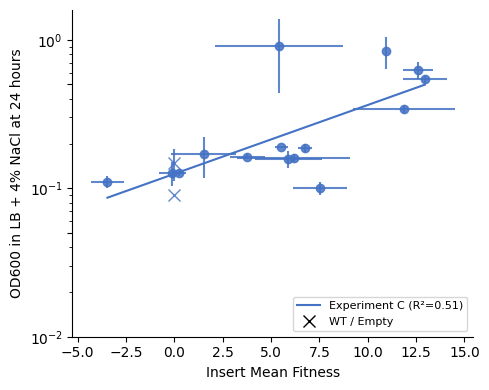

In [8]:
CONTROL_STRAINS = ["s.Ek.E.01683", "s.Ek.X.01535"]  # Empty, WT
COLOR = "#4472C4"

validation_data = pd.read_csv(DATA_DIR / "clonal_validation_data.csv")

validation_data_wFitness = validation_data.merge(
    bc_fitness_means[["bc_sequence", "mean_fitness_corrected", "std_fitness"]],
    left_on="Barcode", right_on="bc_sequence", how="left",
)

### Fill NA with 0
validation_data_wFitness["mean_fitness_corrected"] = validation_data_wFitness["mean_fitness_corrected"].fillna(0)
validation_data_wFitness["std_fitness"] = validation_data_wFitness["std_fitness"].fillna(0)

expt_C = validation_data_wFitness[validation_data_wFitness["Experiment"] == "C"].copy()
expt_C["log_od600"] = np.log10(expt_C["OD600_corrected_mean"])
expt_C["is_control"] = expt_C["Strain Name"].isin(CONTROL_STRAINS)

fig, ax = plt.subplots(figsize=(5, 4))

for is_control, marker, ms in [(False, "o", 6), (True, "x", 9)]:
    pts = expt_C[expt_C["is_control"] == is_control]
    if pts.empty:
        continue
    ax.errorbar(
        pts["mean_fitness_corrected"], pts["OD600_corrected_mean"],
        yerr=pts["OD600_corrected_std"], xerr=pts["std_fitness"],
        fmt=marker, color=COLOR, ecolor=COLOR, alpha=0.85, markersize=ms,
    )

# Best-fit line: regression is fit on log10(OD600), since the y-axis is log-scaled.
fit_C = smf.ols("log_od600 ~ mean_fitness_corrected", data=expt_C).fit()
x_line = np.linspace(expt_C["mean_fitness_corrected"].min(), expt_C["mean_fitness_corrected"].max(), 100)
y_line = 10 ** fit_C.predict(pd.DataFrame({"mean_fitness_corrected": x_line}))
ax.plot(x_line, y_line, color=COLOR, linewidth=1.5, label=f"Experiment C (R\u00b2={fit_C.rsquared:.2f})")

# Marker-shape legend entry for the WT/Empty controls.
control_proxy = Line2D([], [], color="black", marker="x", linestyle="none", markersize=8)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [control_proxy], labels=labels + ["WT / Empty"], fontsize=8, loc="lower right")

ax.set_xlabel("Insert Mean Fitness")
ax.set_yscale("log")
ax.set_yticks([0.01, 0.05, 0.1, 0.5, 1])
ax.set_ylabel("OD600 in LB + 4% NaCl at 24 hours")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

fig.savefig(RESULTS_DIR / "figureS1a_validation_experiment_c.pdf", bbox_inches="tight")


### Linear model summary

Only one experiment here, so there's no experiment-vs-fitness variance decomposition to do (that
comparison is in `figure2.ipynb`'s Figure 2c, which covers Experiments A and B) -- just the single
`log10(OD600) ~ mean_fitness_corrected` fit.

In [5]:
print("=" * 78)
print("Experiment C")
print("=" * 78)
print(fit_C.summary())


Experiment C
                            OLS Regression Results                            
Dep. Variable:              log_od600   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     15.45
Date:                Wed, 12 Aug 2026   Prob (F-statistic):            0.00133
Time:                        18:38:44   Log-Likelihood:                 1.5014
No. Observations:                  17   AIC:                            0.9971
Df Residuals:                      15   BIC:                             2.664
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept      